# Configuration

In [1]:
import os 

if True ^ os.getcwd().endswith('hte-and-targeting'):
    os.chdir('..')

In [2]:
import pandas as pd 
import numpy as np

In [3]:
from scipy.stats import norm, invgamma
# estimators
# from econml.grf import CausalForest
from statsmodels.regression.linear_model import OLS, WLS

from scipy.integrate import quad 
from scipy.stats import ks_2samp

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
import plotly.express as px
import plotly.graph_objects as go

plt.rcParams['text.usetex'] = False

In [5]:
from core.variables import * 
from core.estimators import *
from core.dgp import *
from core.experiments import *
from core.visualization import *

# Experiments

In [45]:
# parameters
train_size = 100
test_size = 10
num_groups = 2
te_diff = 0.1
group_func = lambda x: 0 if x < 0 else 1

# initialize the data generating process
dgp = DGP1(
    num_groups=num_groups, te_diff=te_diff, group_func=group_func, noise_std=1.0, treatment_assign_prob=0.5
)

train_x, train_t, train_y = dgp.generate_training_data(train_size)
test_x = dgp.generate_testing_data(test_size)

# train estimators 
plugin_estimator = BinaryPlugIn(dgp.group_func, num_groups).fit(train_x, train_t, train_y)  # plugin estimator
corr_estimator = BinaryCorrection(dgp.group_func, n_groups=num_groups).fit(train_x, train_t, train_y, n_bootstraps=500)  # bootstrap correction estimator
mnb_corr_estimator = BinaryMNBCorrection(dgp.group_func, n_groups=num_groups).fit(train_x, train_t, train_y, n_bootstraps=500, q=0.9, max_j=20)  # m-out-of-n bootstrap correction estimator
adj_corr_estimator = BinaryAdjustedCorrection(dgp.group_func, n_groups=num_groups).fit(train_x, train_t, train_y, n_bootstraps=5000)  # adjusted bootstrap correction estimator
# pb_corr_estimator = BinaryPBCorrection(dgp.group_func, n_groups=num_groups).fit(train_x, train_t, train_y)  # parametric bootstrap correction estimator
# bb_corr_estimator = BinaryBBCorrection(dgp.group_func, n_groups=num_groups).fit(train_x, train_t, train_y)  # non-parametric bootstrap correction estimator
# param_estimator = BinaryParametric(dgp.group_func, n_groups=num_groups).fit(train_x, train_t, train_y)  # parametric estimator

In [46]:
# evalute test set 
budget = 1

best_targ_val = get_best_targeting_val(test_x, dgp, budget=budget)
plugin_targ_est = plugin_estimator.estimate_targeting_value(test_x, budget=budget)
true_plugin_targ_val = evaluate_targeting_policy(test_x, plugin_estimator.get_targeting_decision(test_x, budget), dgp, budget=budget)
correction_target_est = corr_estimator.estimate_targeting_value(test_x, budget=budget)
adj_corr_target_est = adj_corr_estimator.estimate_targeting_value(test_x, budget=budget)
# pb_corr_target_est = pb_corr_estimator.estimate_targeting_value(test_x, budget=budget)
# bb_corr_target_est = bb_corr_estimator.estimate_targeting_value(test_x, budget=budget)
mnb_corr_target_est = mnb_corr_estimator.estimate_targeting_value(test_x, budget=budget)
# param_target_est = param_estimator.estimate_targeting_value(test_x, budget=budget)

print(f"Best targeting value: {best_targ_val:.4f}\n")

print(f"Plugin targeting estimate: {plugin_targ_est:.4f}")
print(f"Correction targeting estimate: {correction_target_est:.4f}")
print(f"Adjusted correction targeting estimate: {adj_corr_target_est:.4f}")
# print(f"Parametric bootstrap targeting estimate: {pb_corr_target_est:.4f}")
# print(f"Bayesian bootstrap targeting estimate: {bb_corr_target_est:.4f}")
print(f"M-out-of-n bootstrap targeting estimate: {mnb_corr_target_est:.4f}")
# print(f"Parametric targeting estimate: {param_target_est:.4f}")

print(f"\nActual value of plugin targeting: {true_plugin_targ_val:.4f}")
print(f"Winner's Curse of plugin estimate: {plugin_targ_est - true_plugin_targ_val:.4f}")
print(f"Winner's Curse of correction estimat: {correction_target_est - true_plugin_targ_val:.4f}")
print(f"Winner's Curse of adjusted correction estimate: {adj_corr_target_est - true_plugin_targ_val:.4f}")
# print(f"Winner's Curse of parametric bootstrap estimate: {pb_corr_target_est - true_plugin_targ_val:.4f}")
# print(f"Winner's Curse of Bayesian bootstrap estimate: {bb_corr_target_est - true_plugin_targ_val:.4f}")
print(f"Winner's Curse of M-out-of-n bootstrap estimate: {mnb_corr_target_est - true_plugin_targ_val:.4f}")
# print(f"Winner's Curse of parametric estimate: {param_target_est - true_plugin_targ_val:.4f}")

Best targeting value: 1.1000

Plugin targeting estimate: 1.3968
Correction targeting estimate: 1.2357
Adjusted correction targeting estimate: 1.2528
M-out-of-n bootstrap targeting estimate: 1.0794

Actual value of plugin targeting: 1.0000
Winner's Curse of plugin estimate: 0.3968
Winner's Curse of correction estimat: 0.2357
Winner's Curse of adjusted correction estimate: 0.2528
Winner's Curse of M-out-of-n bootstrap estimate: 0.0794


## Test 1

In [48]:
# parameters
dgp_params = {
    'num_groups': 2,  # number of groups
    'te_diff': 0.1,  # treatment effect difference
    'group_func': lambda x: 0 if x < 0 else 1,  # group function
    'train_size': 100,  # size of training set
    'noise_std': 1.0,  # standard deviation of the noise
}
targeting_params = {
    'size': 10,  # number of arriving customers
    'budget': 1,  # number of customers to target
}
estimators_dict = {
    'plugin': {
        'estimator': BinaryPlugIn, 
        'train_params': {}, 
        'targeting_params': {}, 
    },  # plugin estimator
    'correction': {
        'estimator': BinaryCorrection, 
        'train_params': {'n_bootstraps': 1000},
        'targeting_params': {},
    },  # bootstrap correction estimator
    # 'adj_correction': {
    #     'estimator': BinaryAdjustedCorrection, 
    #     'train_params': {'n_bootstraps': 1000},
    #     'targeting_params': {},
    # },  # adjusted bootstrap correction estimator, 
    # 'pb_correction': {
    #     'estimator': BinaryPBCorrection, 
    #     'train_params': {},
    #     'targeting_params': {'n_bootstraps': 1000},
    # },  # parametric bootstrap correction estimator
    # 'bb_correction': {
    #     'estimator': BinaryBBCorrection, 
    #     'train_params': {'n_bootstraps': 1000},
    #     'targeting_params': {},
    # },  # non-parametric bootstrap correction estimator
    'mnb_correction': {
        'estimator': BinaryMNBCorrection, 
        'train_params': {'n_bootstraps': 1000, 'q': 0.95, 'max_j': 20},
        'targeting_params': {},
    },  # m-out-of-n bootstrap correction estimator
    # 'parametric': {
    #     'estimator': BinaryParametric, 
    #     'train_params': {},
    #     'targeting_params': {},
    # },  # parametric estimator
}

In [49]:
grid_results = grid_experiment(
    sample_sizes=[100, 300, 500, 700, 900, 1000],
    num_bootstraps=[100],
    noise_stds=[1.0],
    te_diffs=[0.1], 
    dgp_params=dgp_params,
    targeting_params=targeting_params,
    estimators_dict=estimators_dict,
    save_dir='results/test2.csv',
    num_test_groups=50, num_repeats_per_test_group=50, 
    verbose=True
)

Fixed knob values: 
num_bootstrap=100
noise_std=1.0
te_diff=0.1


Fixed Knobs:  num_bootstrap: 500.0, noise_std: 1.0, te_diff: 0.1, 

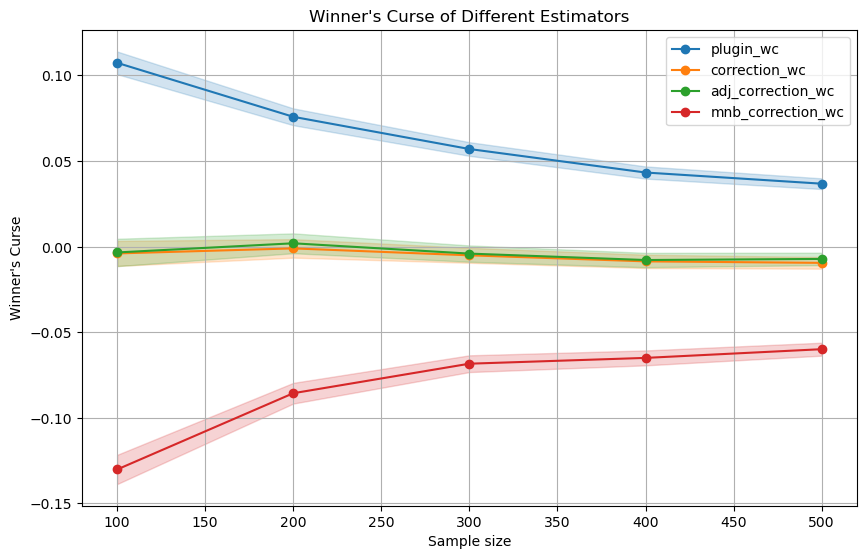

In [11]:
plot_winners_curse_2d(
    'results/test.csv', 
    x='sample_size', confidence_level=0.95, 
)

Fixed Knobs:  num_bootstrap: 500.0, noise_std: 1.0, te_diff: 0.1, 

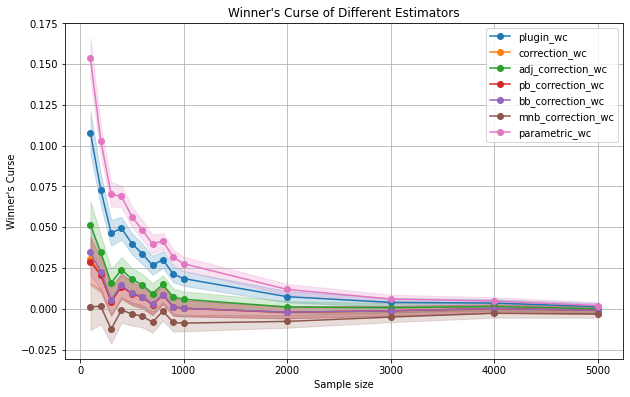

In [ ]:
plot_winners_curse_2d(
    'results/sample_size_test.csv', 
    x='sample_size', confidence_level=0.95, 
)

In [ ]:
grid_results = grid_experiment(
    sample_sizes=[1000], 
    num_bootstraps=[100],
    noise_stds=[1.0],
    te_diffs=[0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5], 
    dgp_params=dgp_params,
    targeting_params=targeting_params,
    estimators_dict=estimators_dict,
    save_dir='results/te_diff_test.csv',
    num_test_groups=50, num_repeats_per_test_group=50, 
    verbose=True
)

Fixed knob values: 
sample_size=1000
num_bootstrap=1000
noise_std=1.0
te_diff=0.05, Time taken: 0:19:32.370260
te_diff=0.1, Time taken: 0:19:35.272520
te_diff=0.15, Time taken: 0:19:21.236115
te_diff=0.2, Time taken: 0:18:48.787112
te_diff=0.25, Time taken: 0:18:17.428766
te_diff=0.3, Time taken: 0:17:23.651810
te_diff=0.35, Time taken: 0:16:48.781206
te_diff=0.4, Time taken: 0:16:16.667947
te_diff=0.45, Time taken: 0:16:03.825968
te_diff=0.5, Time taken: 0:15:49.728008


Fixed Knobs:  sample_size: 1000.0, num_bootstrap: 1000.0, noise_std: 1.0, 

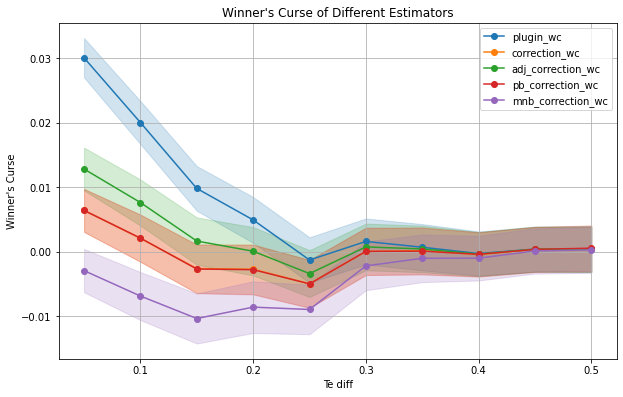

In [ ]:
plot_winners_curse_2d(
    'results/te_diff_test.csv', 
    x='te_diff', confidence_level=0.95, 
)

In [ ]:
grid_results = grid_experiment(
    sample_sizes=[1000], 
    num_bootstraps=[100],
    noise_stds=[0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0],
    te_diffs=[0.1], 
    dgp_params=dgp_params,
    targeting_params=targeting_params,
    estimators_dict=estimators_dict,
    save_dir='results/noise_std_test.csv',
    num_test_groups=50, num_repeats_per_test_group=50, 
    verbose=True
)

Fixed knob values: 
sample_size=1000
num_bootstrap=1000
te_diff=0.1
noise_std=0.5, Time taken: 0:18:51.571336
noise_std=1.0, Time taken: 0:19:31.541217
noise_std=1.5, Time taken: 0:19:33.501919
noise_std=2.0, Time taken: 0:19:30.452714
noise_std=2.5, Time taken: 0:19:31.248806
noise_std=3.0, Time taken: 0:19:26.849934
noise_std=3.5, Time taken: 0:19:32.569413
noise_std=4.0, Time taken: 0:19:31.560173
noise_std=4.5, Time taken: 0:19:30.762510
noise_std=5.0, Time taken: 0:19:34.757635


Fixed Knobs:  sample_size: 1000.0, num_bootstrap: 1000.0, te_diff: 0.1, 

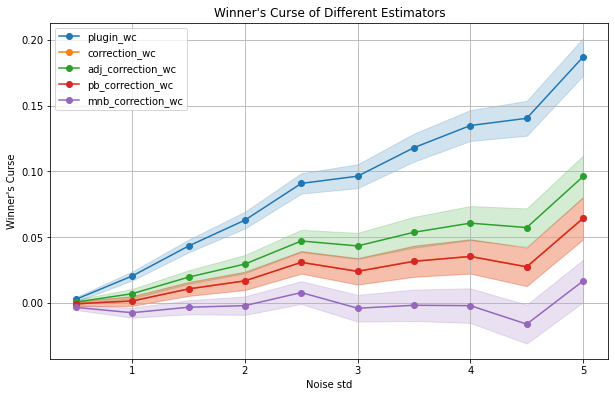

In [ ]:
plot_winners_curse_2d(
    'results/noise_std_test.csv', 
    x='noise_std', confidence_level=0.95, 
)

## Test 2

In [ ]:
# parameters
def group_func(x):
    if x <= -1.5:
        return 0
    elif x <= 0:
        return 1
    elif x <= 1.5:
        return 2
    else:
        return 3
    
# parameters
dgp_params = {
    'num_groups': 4,  # number of groups
    'te_diff': 0.1,  # treatment effect difference
    'group_func': group_func,  # group function
    'train_size': 100,  # size of training set
    'noise_std': 1.0,  # standard deviation of the noise
}
targeting_params = {
    'size': 20,  # number of arriving customers
    'budget': 5,  # number of customers to target
}
estimators_dict = {
    'plugin': {
        'estimator': BinaryPlugIn, 
        'train_params': {}, 
        'targeting_params': {}, 
    },  # plugin estimator
    'correction': {
        'estimator': BinaryCorrection, 
        'train_params': {'n_bootstrap': 1000},
        'targeting_params': {},
    },  # bootstrap correction estimator
    'adj_correction': {
        'estimator': BinaryAdjustedCorrection, 
        'train_params': {'n_bootstrap': 1000},
        'targeting_params': {},
    },  # adjusted bootstrap correction estimator, 
}

In [ ]:
grid_results = grid_experiment(
    sample_sizes=[100, 200, 300, 400, 500, 1000, 2000, 3000, 4000, 5000], 
    num_bootstraps=[500],
    noise_stds=[0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0],
    te_diffs=[0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5], 
    dgp_params=dgp_params,
    targeting_params=targeting_params,
    estimators_dict=estimators_dict,
    save_dir='results/wc_grid2.csv',
    num_repeats=50, verbose=True
)

Sample size: 100, Num bootstrap: 5000, Time taken: 169.08 seconds
Sample size: 100, Num bootstrap: 10000, Time taken: 338.05 seconds
Sample size: 100, Num bootstrap: 15000, Time taken: 518.35 seconds
Sample size: 100, Num bootstrap: 20000, Time taken: 686.76 seconds
Sample size: 500, Num bootstrap: 5000, Time taken: 175.74 seconds
Sample size: 500, Num bootstrap: 10000, Time taken: 361.12 seconds
Sample size: 500, Num bootstrap: 15000, Time taken: 541.05 seconds
Sample size: 500, Num bootstrap: 20000, Time taken: 717.27 seconds
Sample size: 1000, Num bootstrap: 5000, Time taken: 186.74 seconds
Sample size: 1000, Num bootstrap: 10000, Time taken: 2289.31 seconds
Sample size: 1000, Num bootstrap: 15000, Time taken: 1538.88 seconds
Sample size: 1000, Num bootstrap: 20000, Time taken: 775.34 seconds
Sample size: 1500, Num bootstrap: 5000, Time taken: 197.85 seconds
Sample size: 1500, Num bootstrap: 10000, Time taken: 399.24 seconds
Sample size: 1500, Num bootstrap: 15000, Time taken: 607.1

# Sketch

In [14]:
# parameters
train_size = 100
test_size = 10
num_groups = 2
te_diff = 0.1
group_func = lambda x: 0 if x < 0 else 1

# initialize the data generating process
dgp = DGP1(
    num_groups=num_groups, te_diff=te_diff, group_func=group_func, noise_std=1.0, treatment_assign_prob=0.5
)

train_x, train_t, train_y = dgp.generate_training_data(train_size)
test_x = dgp.generate_testing_data(test_size)

In [36]:
mnb_corr_estimator = BinaryMNBCorrection(dgp.group_func, n_groups=num_groups).fit(train_x, train_t, train_y, n_bootstraps=500, q=0.95, max_j=20)  # m-out-of-n bootstrap correction estimator

In [37]:
mnb_corr_estimator.estimate_targeting_value(test_x, budget=budget)

1.148269749177544